In [144]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df = \
    read_model_runs('../../data/processed/model-runs')



In [145]:
from read_model_runs import filter_complete_questions

models = ['gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3-4b-it']
firacs = ['FILA_', 'FIR__', 'FI___', 'FIL__', '_____', 'unstructured']
question_long_df, question_wide_df, model_order, firac_order = filter_complete_questions(question_long_df, models, firacs)

print('shape:', question_long_df.shape)
print('# unique questions:', question_long_df['question_id'].nunique())
print("model order:", model_order)
print("firac order:", firac_order)


shape: (42210, 32)
# unique questions: 2345
model order: ['gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it']
firac order: ['_____', 'unstructured', 'FIL__', 'FI___', 'FIR__', 'FILA_']


In [146]:
question_wide_df.head()

,question_id,model_name,_____,unstructured,FIL__,FI___,FIR__,FILA_
0,oab-1.pdf-002,gemma-3-12b-it,False,True,True,True,True,True
1,oab-1.pdf-002,gemma-3-27b-it,False,True,True,True,True,True
2,oab-1.pdf-002,gemma-3-4b-it,True,True,True,True,True,True
3,oab-1.pdf-003,gemma-3-12b-it,False,False,False,False,True,True
4,oab-1.pdf-003,gemma-3-27b-it,False,False,True,True,True,True


In [147]:
question_wide_df.columns

Index(['question_id', 'model_name', '_____', 'unstructured', 'FIL__', 'FI___', 'FIR__', 'FILA_'], dtype='object')

In [148]:
import pandas as pd

pca_df = pd.read_csv("../../data/processed/pca.csv")

pca_df.head()

,Unnamed: 0,materia,tema,oab_test_id,question_id,PC1,PC2,PC3,PC4,PC5,...,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
0,0,ÉTICA PROFISSIONAL,DIREITOS DO ADVOGADO,XV,oab-1.pdf-002,1.963886,0.247445,1.438977,0.136820,0.030276,...,0.052654,0.433758,0.574385,-0.386226,-1.032898,-0.345120,-1.531358,-0.273165,0.621459,0.251065
1,1,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XV,oab-1.pdf-003,-2.198704,1.827469,-0.392541,0.716089,-1.272295,...,0.276380,0.438431,1.306208,0.940574,0.606896,-0.382623,-0.489931,0.062937,0.152470,0.134650
2,2,ÉTICA PROFISSIONAL,SOCIEDADE DE ADVOGADOS,XV,oab-1.pdf-004,1.134510,0.460976,-1.310597,0.056790,-0.475456,...,0.886844,1.103818,0.866351,-1.187548,-0.626724,0.405295,-0.473842,-1.100276,-0.154992,-0.065863
3,3,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XIV,oab-1.pdf-005,0.113715,-6.675350,-0.199894,0.107841,0.749690,...,2.557660,-3.328763,0.455791,1.493676,-1.840929,-0.016450,0.443545,0.451682,0.202169,0.226066
4,4,ÉTICA PROFISSIONAL,ÉTICA DO ADVOGADO,XIV,oab-1.pdf-006,2.132751,-0.111454,-0.839197,-0.192117,0.097045,...,0.856657,1.140298,0.289010,0.325660,-0.011040,-0.072027,0.100733,-0.060244,0.040731,-0.069990


In [149]:
import pandas as pd

# --------------------------------------------------
# Extrair enunciado único por question_id
# e concatenar alternativas A–D
# --------------------------------------------------
enunciado_df = (
    question_long_df
    .loc[:, ["question_id", "enunciado", "A", "B", "C", "D"]]
    .drop_duplicates(subset="question_id")
    .assign(
        enunciado=lambda df: (
            df["enunciado"].astype(str)
            + " A) " + df["A"].astype(str)
            + " B) " + df["B"].astype(str)
            + " C) " + df["C"].astype(str)
            + " D) " + df["D"].astype(str)
        )
    )
    .loc[:, ["question_id", "enunciado"]]  # remove A, B, C, D
)

# --------------------------------------------------
# Merge: trazer enunciado enriquecido para o PCA
# --------------------------------------------------
pca_df = (
    pca_df
    .merge(
        enunciado_df,
        on="question_id",
        how="left",
        validate="one_to_one"
    )
)

pca_df.head()


,Unnamed: 0,materia,tema,oab_test_id,question_id,PC1,PC2,PC3,PC4,PC5,...,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,enunciado
0,0,ÉTICA PROFISSIONAL,DIREITOS DO ADVOGADO,XV,oab-1.pdf-002,1.963886,0.247445,1.438977,0.136820,0.030276,...,0.433758,0.574385,-0.386226,-1.032898,-0.345120,-1.531358,-0.273165,0.621459,0.251065,"Fred, jovem advogado, é contratado para prestar serviços na empresa BBO Ltda., que\npossui uma assessoria jurídica composta por cinco profissionais do Direito, orientados\npor uma gerência jurídica. Após cinco meses de intensa atividade, é concitado a\nformular parecer sobre determinado tema jurídico de interesse da empresa, tarefa que\nrealiza, sendo seu entendimento subscrito pela gerência.\nApós dez meses do referido evento, o tema é reapresentado por um dos diretores da\nempresa, que, em viagem realizada para outro estado, havia consultado um outro\nadvogado. Diante dos novos argumentos, o gerente determina que Fred, o advogado\nparecerista, mesmo sem ter mudado de opinião, apresente petição inicial em confronto\ncom o entendimento anteriormente preconizado.\nNo caso, nos termos do Código de Ética da Advocacia, o advogado A) pode opor-se e postular assessoria da OAB. B) pode recusar-se a propor a ação diante do parecer anterior. C) deve apresentar seu parecer ao conjunto de advogados para decisão. D) deve submeter-se à determinação da gerência jurídica."
1,1,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XV,oab-1.pdf-003,-2.198704,1.827469,-0.392541,0.716089,-1.272295,...,0.438431,1.306208,0.940574,0.606896,-0.382623,-0.489931,0.062937,0.152470,0.134650,"O advogado Caio atuava representando os interesses do autor em determinada ação\nindenizatória há alguns anos. Antes da prolação da sentença, substabeleceu, com\nreserva, os poderes que lhe haviam sido outorgados pelo cliente, ao advogado Tício.\nAo final, o pedido foi julgado procedente e o cliente de Caio e Tício recebeu a\nindenização pleiteada, mas não repassou aos advogados os honorários de êxito\ncontratados, estipulados em 30%. Caio, para evitar desgaste, preferiu não cobrar\njudicialmente os valores devidos pelo cliente. Tício, não concordando com a opção de\nCaio, decidiu, à revelia deste último, ingressar com a ação cabível, valendo-se, para\ntanto, do contrato de honorários celebrado entre Caio e o cliente.\nA partir do caso apresentado, assinale a afirmativa correta. A) Tício não pode ajuizar tal ação porque, como Caio e Tício não requereram o\ndestaque dos honorários contratuais, ele não tem mais direito a recebê-los. B) Tício não pode ajuizar tal ação porque o advogado substabelecido com reserva\nde poderes não pode cobrar honorários sem a intervenção daquele que lhe\nconferiu o substabelecimento. C) Tício pode ajuizar tal ação, pois, embora não tivesse celebrado o contrato com o\ncliente, recebeu poderes de Caio para atuar na causa. D) Tício pode ajuizar tal ação, pois ingressou na causa antes da prolação da\nsentença, sendo, assim, igualmente responsável pelo êxito."
2,2,ÉTICA PROFISSIONAL,SOCIEDADE DE ADVOGADOS,XV,oab-1.pdf-004,1.134510,0.460976,-1.310597,0.056790,-0.475456,...,1.103818,0.866351,-1.187548,-0.626724,0.405295,-0.473842,-1.100276,-0.154992,-0.065863,"Os advogados X de Souza, Y dos Santos e Z de Andrade requereram o registro de\nsociedade de advogados denominada Souza, Santos e Andrade Sociedade de\nAdvogados. Tempos depois, X de Souza vem a falecer, mas os demais sócios decidem\nmanter na sociedade o nome do advogado falecido.\nSobre a hipótese, assinale a afirmativa correta. A) É possível manter o nome do sócio falecido, independentemente de previsão no\nato constitutivo da sociedade. B) É absolutamente vedada a manutenção do nome do sócio falecido na razão\nsocial da sociedade. C) É possível manter o nome do sócio falecido, desde que prevista tal possibilidade\nno ato constitutivo da sociedade. D) É possível manter, pelo prazo máximo de seis meses, o nome do sócio falecido."
3,3,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XIV,oa

In [150]:
import pandas as pd
import numpy as np

df = pca_df.copy()

required_cols = {"PC1", "PC2", "materia", "tema", "question_id"}
assert required_cols.issubset(df.columns)


In [151]:
import pandas as pd
import json

def show_question(question_long_df, question_id):
    exam_df = pd.read_csv(f"../../data/processed/oab_with_firac_portuguese_shuffle.csv")
    exam_df = exam_df[exam_df.question_id == question_id]

    filtered_df = question_long_df[question_long_df.question_id == question_id]
    filtered_df = filtered_df[filtered_df.firac == '_____']

    question = exam_df.iloc[0]

    print(f"Enunciado: {question['enunciado']}\n")
    print(f"A) {question['A']}")
    print(f"B) {question['B']}")
    print(f"C) {question['C']}")
    print(f"D) {question['D']}")

    # Imprime todos os Facts com o modelo
    print("\n=== Facts ===")
    print(f"Gabarito: {question['Facts']}")
    print("*****")
    for index, row in filtered_df.iterrows():
        print(f"Modelo: {row['model_name']}, {row['Facts']}")

    # Imprime todos os Issues com o modelo
    print("\n=== Issue ===")
    print(f"Gabarito: {question['Issue']}")
    print("*****")
    for index, row in filtered_df.iterrows():
        print(f"Modelo: {row['model_name']}, {row['Issue']}")

    # Imprime todas as Rules com o modelo
    print("\n=== Rule ===\nGabarito:\n")
    print("".join(f"{k} → {item}" for k, v in json.loads(question['Rule']).items() if v for item in v))
    print("*****")
    for index, row in filtered_df.iterrows():
        print(f"Modelo: {row['model_name']} -- {row['Rule']}")

    # Imprime todas as Applications com o modelo
    print("\n=== Application ===")
    print(f"Gabarito: {question['Application']}")
    print("*****")
    for index, row in filtered_df.iterrows():
        print(f"Modelo: {row['model_name']} -- {row['Application']}")

    # Imprime todas as Conclusions com o modelo
    print("\n=== Conclusion ===")
    print(f"Gabarito: {question['Conclusion']}")
    print("*****")
    for index, row in filtered_df.iterrows():
        print(f"Modelo: {row['model_name']} -- {row['Conclusion']}")


    print("\n=== Resposta ===")
    print(f"Gabarito: {question['correct_option']}")
    print("*****")
    for index, row in filtered_df.iterrows():
        print(f"Modelo: {row['model_name']} -- {row['chosen_option']}, {row[row['chosen_option']]}")


In [152]:
show_question(question_long_df, "oab-167.pdf-150")

Enunciado: Antônio, vendedor, celebrou contrato de compra e venda com Joaquim, comprador, no
dia 1º de setembro de 2016, cujo objeto era um carro da marca X no valor de R$
20.000,00, sendo o pagamento efetuado à vista na data de assinatura do contrato.
Ficou estabelecido ainda que a entrega do bem seria feita 30 dias depois, em 1º de
outubro de 2016, na cidade do Rio de Janeiro, domicílio do vendedor. Contudo, no dia
25 de setembro, uma chuva torrencial inundou diversos bairros da cidade e o carro foi
destruído pela enchente, com perda total. Considerando a descrição dos fatos,
Joaquim

A) terá direito à devolução de 50% do valor, tendo em vista que Antônio, vendedor,
teve culpa.
B) terá direito à devolução de 100% do valor, pois ainda não havia ocorrido a
tradição no momento do perecimento do bem.
C) terá direito à devolução de 50% do valor, tendo em vista que Antônio, vendedor,
não teve culpa.
D) não faz jus à devolução do pagamento de R$ 20.000,00.

=== Facts ===
Gabarito: [
  "Antô

In [153]:
import numpy as np

def assign_quadrant(sub_df):
    pc1_med = 0  # sub_df["PC1"].median()
    pc2_med = 0  # sub_df["PC2"].median()

    conditions = [
        (sub_df["PC1"] >= pc1_med) & (sub_df["PC2"] >= pc2_med),
        (sub_df["PC1"] >= pc1_med) & (sub_df["PC2"] <  pc2_med),
        (sub_df["PC1"] <  pc1_med) & (sub_df["PC2"] >= pc2_med),
        (sub_df["PC1"] <  pc1_med) & (sub_df["PC2"] <  pc2_med),
    ]

    # PC1 alto = fácil | PC1 baixo = difícil
    labels = [
        "easy_processual",    # PC1 alto, PC2 alto
        "easy_material",      # PC1 alto, PC2 baixo
        "hard_processual",    # PC1 baixo, PC2 alto
        "hard_material",      # PC1 baixo, PC2 baixo
    ]

    sub_df = sub_df.copy()
    sub_df["quadrant"] = np.select(conditions, labels)

    # --------------------------------------------------
    # Colocar 'quadrant' como primeira coluna
    # --------------------------------------------------
    cols = ["quadrant"] + [c for c in sub_df.columns if c != "quadrant"]
    sub_df = sub_df[cols]

    return sub_df


question_df = (
    df
    .groupby("materia", group_keys=False)
    .apply(assign_quadrant)
)


C:\Users\pedro\AppData\Local\Temp\ipykernel_16064\4067494197.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_quadrant)


In [154]:
question_df

,quadrant,Unnamed: 0,materia,tema,oab_test_id,question_id,PC1,PC2,PC3,PC4,...,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,enunciado
0,easy_processual,0,ÉTICA PROFISSIONAL,DIREITOS DO ADVOGADO,XV,oab-1.pdf-002,1.963886,0.247445,1.438977,0.136820,...,0.433758,0.574385,-0.386226,-1.032898,-0.345120,-1.531358,-0.273165,0.621459,0.251065,"Fred, jovem advogado, é contratado para prestar serviços na empresa BBO Ltda., que\npossui uma assessoria jurídica composta por cinco profissionais do Direito, orientados\npor uma gerência jurídica. Após cinco meses de intensa atividade, é concitado a\nformular parecer sobre determinado tema jurídico de interesse da empresa, tarefa que\nrealiza, sendo seu entendimento subscrito pela gerência.\nApós dez meses do referido evento, o tema é reapresentado por um dos diretores da\nempresa, que, em viagem realizada para outro estado, havia consultado um outro\nadvogado. Diante dos novos argumentos, o gerente determina que Fred, o advogado\nparecerista, mesmo sem ter mudado de opinião, apresente petição inicial em confronto\ncom o entendimento anteriormente preconizado.\nNo caso, nos termos do Código de Ética da Advocacia, o advogado A) pode opor-se e postular assessoria da OAB. B) pode recusar-se a propor a ação diante do parecer anterior. C) deve apresentar seu parecer ao conjunto de advogados para decisão. D) deve submeter-se à determinação da gerência jurídica."
1,hard_processual,1,ÉTICA PROFISSIONAL,ATIVIDADE DE ADVOCACIA,XV,oab-1.pdf-003,-2.198704,1.827469,-0.392541,0.716089,...,0.438431,1.306208,0.940574,0.606896,-0.382623,-0.489931,0.062937,0.152470,0.134650,"O advogado Caio atuava representando os interesses do autor em determinada ação\nindenizatória há alguns anos. Antes da prolação da sentença, substabeleceu, com\nreserva, os poderes que lhe haviam sido outorgados pelo cliente, ao advogado Tício.\nAo final, o pedido foi julgado procedente e o cliente de Caio e Tício recebeu a\nindenização pleiteada, mas não repassou aos advogados os honorários de êxito\ncontratados, estipulados em 30%. Caio, para evitar desgaste, preferiu não cobrar\njudicialmente os valores devidos pelo cliente. Tício, não concordando com a opção de\nCaio, decidiu, à revelia deste último, ingressar com a ação cabível, valendo-se, para\ntanto, do contrato de honorários celebrado entre Caio e o cliente.\nA partir do caso apresentado, assinale a afirmativa correta. A) Tício não pode ajuizar tal ação porque, como Caio e Tício não requereram o\ndestaque dos honorários contratuais, ele não tem mais direito a recebê-los. B) Tício não pode ajuizar tal ação porque o advogado substabelecido com reserva\nde poderes não pode cobrar honorários sem a intervenção daquele que lhe\nconferiu o substabelecimento. C) Tício pode ajuizar tal ação, pois, embora não tivesse celebrado o contrato com o\ncliente, recebeu poderes de Caio para atuar na causa. D) Tício pode ajuizar tal ação, pois ingressou na causa antes da prolação da\nsentença, sendo, assim, igualmente responsável pelo êxito."
2,easy_processual,2,ÉTICA PROFISSIONAL,SOCIEDADE DE ADVOGADOS,XV,oab-1.pdf-004,1.134510,0.460976,-1.310597,0.056790,...,1.103818,0.866351,-1.187548,-0.626724,0.405295,-0.473842,-1.100276,-0.154992,-0.065863,"Os advogados X de Souza, Y dos Santos e Z de Andrade requereram o registro de\nsociedade de advogados denominada Souza, Santos e Andrade Sociedade de\nAdvogados. Tempos depois, X de Souza vem a falecer, mas os demais sócios decidem\nmanter na sociedade o nome do advogado falecido.\nSobre a hipótese, assinale a afirmativa correta. A) É possível manter o nome do sócio falecido, independentemente de previsão no\nato constitutivo da sociedade. B) É absolutamente vedada a manutenção do nome do sócio falecido na razão\nsocial da sociedade. C) É possível manter o nome do sócio falecido, desde que prevista tal possibilidade\nno ato constitutivo da sociedade. D) É possível manter, pelo prazo máximo de seis meses, o nome do sócio falecido."
3,easy_material,3,ÉTICA PROF

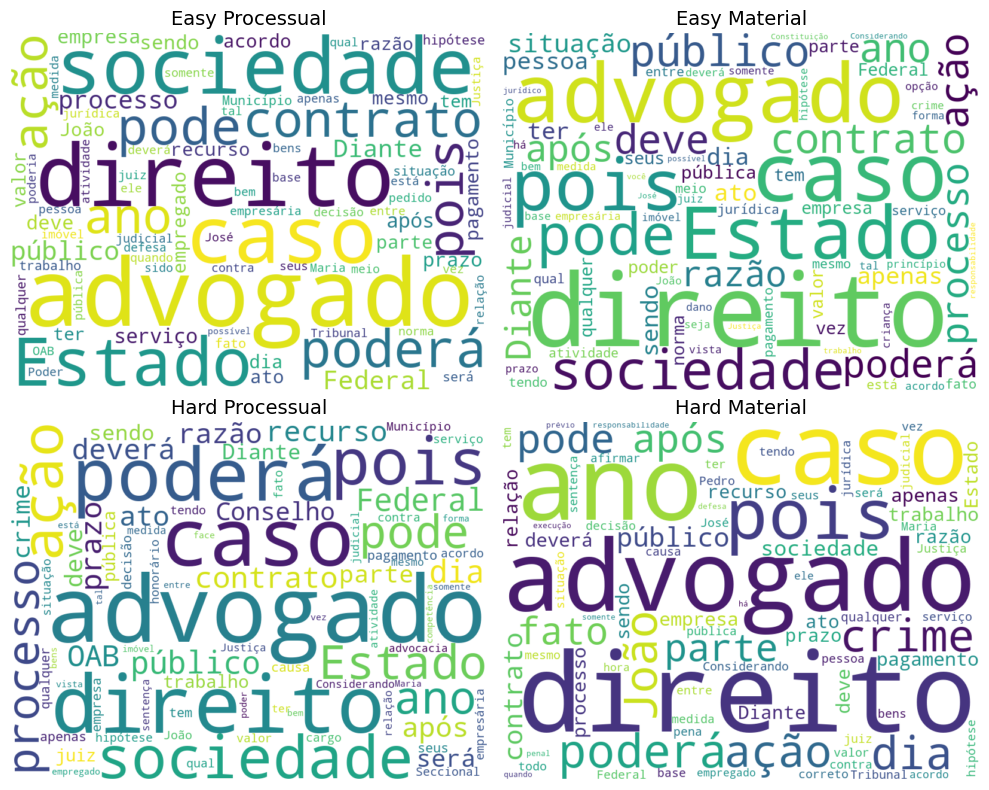

In [163]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import pandas as pd

# --------------------------------------------------
# Stopwords em português (manual + wordcloud)
# --------------------------------------------------
stopwords_pt = {
    "a", "o", "os", "as", "um", "uma", "uns", "umas",
    "de", "do", "da", "dos", "das",
    "em", "no", "na", "nos", "nas",
    "por", "para", "com", "sem", "sobre",
    "e", "ou", "mas", "porque", "que", "se",
    "é", "foi", "são", "era", "ser",
    "ao", "aos", "à", "às",
    "não", "sim",
    "mais", "menos", "muito", "pouco",
    "já", "também", "ainda",
    "lhe", "eles", "elas", "este", "esta", "esses", "essas",
    "isso", "isto", "aquele", "aquela",
    "art", "artigo", "lei", "código", "inciso", "parágrafo",
    "alternativa", "assinale", "correta", "incorreta",
    "questão", "seu", "sua", "pelo", "como", "pela", "afirmativa", "B", "C", "D"
}

STOPWORDS_ALL = STOPWORDS.union(stopwords_pt)

# --------------------------------------------------
# Configurações ACL-style
# --------------------------------------------------
FIGSIZE = (10, 8)
BACKGROUND_COLOR = "white"
MAX_WORDS = 80
COLORMAP = "viridis"
FONT_SIZE = 14

quadrant_order = [
    "easy_processual",
    "easy_material",
    "hard_processual",
    "hard_material",
]

# --------------------------------------------------
# Função para gerar wordcloud
# --------------------------------------------------
def make_wordcloud(text):
    return WordCloud(
        width=800,
        height=600,
        background_color=BACKGROUND_COLOR,
        max_words=MAX_WORDS,
        colormap=COLORMAP,
        stopwords=STOPWORDS_ALL,
        collocations=False
    ).generate(text)


# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)
axes = axes.flatten()

for ax, quadrant in zip(axes, quadrant_order):
    subset = question_df.loc[
        question_df["quadrant"] == quadrant, "enunciado"
    ].dropna()

    if subset.empty:
        ax.axis("off")
        ax.set_title(f"{quadrant}\n(no data)", fontsize=FONT_SIZE)
        continue

    text = " ".join(subset.values)
    wc = make_wordcloud(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(quadrant.replace("_", " ").title(), fontsize=FONT_SIZE)

plt.tight_layout()
plt.show()


In [180]:
import pandas as pd
import numpy as np
import math
import re
from collections import Counter
from wordcloud import STOPWORDS

# ==================================================
# 1. Stopwords (PT-BR + jurídicas + instrucionais)
# ==================================================
stopwords_pt = {
    "a", "o", "os", "as", "um", "uma", "uns", "umas",
    "de", "do", "da", "dos", "das",
    "em", "no", "na", "nos", "nas",
    "por", "para", "com", "sem", "sobre",
    "e", "ou", "mas", "porque", "que", "se",
    "é", "foi", "são", "era", "ser",
    "ao", "aos", "à", "às",
    "não", "sim",
    "mais", "menos", "muito", "pouco",
    "já", "também", "ainda",
    "lhe", "eles", "elas", "este", "esta", "esses", "essas",
    "isso", "isto", "aquele", "aquela",
    "art", "artigo", "lei", "código", "inciso", "parágrafo",
    "alternativa", "assinale", "correta", "incorreta",
    "questão", "questoes"
}

STOPWORDS_ALL = STOPWORDS.union(stopwords_pt)

# ==================================================
# 2. Tokenização
# ==================================================
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zà-ÿ\s]", " ", text)
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS_ALL and len(t) > 2]


# ==================================================
# 3. Log-odds ratio com prior (Monroe et al., 2008)
# ==================================================
def log_odds_ratio_with_prior(counts_target, counts_bg, alpha):
    results = []

    vocab = set(counts_target) | set(counts_bg)
    sum_target = sum(counts_target.values())
    sum_bg = sum(counts_bg.values())
    alpha_0 = sum(alpha.values())

    for word in vocab:
        k_i = counts_target.get(word, 0)
        k_j = counts_bg.get(word, 0)
        alpha_i = alpha.get(word, 1e-6)

        log_odds = math.log(
            (k_i + alpha_i) / (sum_target + alpha_0 - k_i - alpha_i)
        ) - math.log(
            (k_j + alpha_i) / (sum_bg + alpha_0 - k_j - alpha_i)
        )

        var = (1 / (k_i + alpha_i)) + (1 / (k_j + alpha_i))
        z = log_odds / math.sqrt(var)

        results.append((word, log_odds, z, k_i, k_j))

    return pd.DataFrame(
        results,
        columns=["word", "log_odds", "z", "freq_target", "freq_bg"]
    )


# ==================================================
# 4. Função principal: log-odds por coluna arbitrária
# ==================================================
def compute_logodds(question_df, group_col):
    """
    Calcula log-odds (1 vs resto) para cada valor de group_col.
    group_col ∈ {"quadrant", "materia", "tema", ...}
    """

    assert group_col in question_df.columns, f"Coluna {group_col} não existe"

    df = question_df.copy()

    # Tokenização
    df["tokens"] = (
        df["enunciado"]
        .dropna()
        .apply(tokenize)
    )

    # Prior informativo (frequência global)
    global_counts = Counter(
        token for tokens in df["tokens"] for token in tokens
    )
    total_global = sum(global_counts.values())

    alpha = {
        word: count / total_global
        for word, count in global_counts.items()
    }

    logodds_results = {}

    for value in sorted(df[group_col].dropna().unique()):
        tokens_target = df.loc[df[group_col] == value, "tokens"]
        tokens_bg = df.loc[df[group_col] != value, "tokens"]

        counts_target = Counter(
            token for tokens in tokens_target for token in tokens
        )
        counts_bg = Counter(
            token for tokens in tokens_bg for token in tokens
        )

        df_logodds = (
            log_odds_ratio_with_prior(counts_target, counts_bg, alpha)
            .sort_values("z", ascending=False)
            .reset_index(drop=True)
        )

        logodds_results[value] = df_logodds

    return logodds_results


# ==================================================
# 5. Exemplo de uso
# ==================================================

# Escolha aqui:
# group_col = "quadrant"
# group_col = "materia"
# group_col = "tema"
group_col = "quadrant"

logodds_results = compute_logodds(question_df, group_col)

# ==================================================
# 6. Inspeção rápida
# ==================================================
for group_value, df_g in logodds_results.items():
    print(f"\n=== {group_col.upper()} = {group_value} ===")
    print(
        df_g
        .loc[df_g["freq_target"] >= 5]
        .head(15)[["word", "z", "freq_target"]]
    )



=== QUADRANT = easy_material ===
           word         z  freq_target
0     ambiental  7.574835          112
1      direitos  5.699827          212
2         saúde  5.686787           83
3       criança  5.427228           97
4   ordenamento  5.354580           45
5        ensino  5.271403           48
6         moral  5.253145           43
7       direito  5.123368          472
8      crianças  5.102864           35
9         livro  4.989299           33
10       válida  4.703130           58
11      humanos  4.689802           88
12      cláudia  4.648733           27
13        pacto  4.623316           37
14        casal  4.583077           62

=== QUADRANT = easy_processual ===
             word         z  freq_target
0          contas  6.521885           56
1          eireli  5.339508           19
2         augusto  5.308899           19
3          câmara  4.986132           32
4          adoção  4.911195           41
5       categoria  4.675152           25
6         estágio  

In [179]:
import re
import pandas as pd

def questions_per_group_with_token(question_df, token, group_col):
    """
    Conta quantas QUESTÕES (question_id) por group_col
    contêm o token (case-insensitive).

    group_col: "quadrant", "materia", "tema", etc.
    """

    assert group_col in question_df.columns, f"Coluna '{group_col}' não existe"

    token = token.lower()

    # regex com fronteira de palavra (case-insensitive)
    pattern = re.compile(rf"\b{re.escape(token)}\b", flags=re.IGNORECASE)

    df = question_df.copy()

    # marca se a questão contém o token
    df["has_token"] = df["enunciado"].astype(str).apply(
        lambda x: bool(pattern.search(x))
    )

    # conta questões únicas por grupo
    counts = (
        df[df["has_token"]]
        .groupby(group_col)["question_id"]
        .nunique()
        .rename("n_questions")
        .reset_index()
        .sort_values("n_questions", ascending=False)
    )

    return counts


# --------------------------------------------------
# Exemplos de uso
# --------------------------------------------------
token = "sentença"

# Por quadrante
print(questions_per_group_with_token(question_df, token, group_col="quadrant"))

# Por matéria
print(questions_per_group_with_token(question_df, token, group_col="materia"))

# Por tema
print(questions_per_group_with_token(question_df, token, group_col="tema"))


          quadrant  n_questions
3  hard_processual           68
0    easy_material           50
1  easy_processual           32
2    hard_material           27
                   materia  n_questions
14    PROCESSO DO TRABALHO           42
13          PROCESSO CIVIL           40
15          PROCESSO PENAL           18
16      ÉTICA PROFISSIONAL           15
8            DIREITO PENAL           13
2            DIREITO CIVIL           11
0   DIREITO ADMINISTRATIVO            8
11                     ECA            6
7    DIREITO INTERNACIONAL            5
3   DIREITO CONSTITUCIONAL            5
10        DIREITOS HUMANOS            4
4    DIREITO DO CONSUMIDOR            3
5      DIREITO DO TRABALHO            2
6      DIREITO EMPRESARIAL            2
1        DIREITO AMBIENTAL            1
9       DIREITO TRIBUTÁRIO            1
12               FILOSOFIA            1
                                                 tema  n_questions
49                              RECURSOS TRABALHISTAS

In [176]:
import re

def print_token_context_by_quadrant(question_df, token, window=40):
    """
    Imprime ocorrências do token organizadas por quadrant.
    Cada linha: materia | QID | PC1 | PC2 | trecho do enunciado (±window chars).
    """

    pattern = re.compile(rf"\b({re.escape(token)})\b", flags=re.IGNORECASE)

    for quadrant in sorted(question_df["quadrant"].unique()):
        print("\n" + "=" * 110)
        print(f"QUADRANT: {quadrant.upper()}")
        print("=" * 110)

        sub_df = question_df[question_df["quadrant"] == quadrant]

        found_any = False

        for _, row in sub_df.iterrows():
            text = str(row["enunciado"])
            qid = row["question_id"]
            materia = row["materia"]
            pc1 = row["PC1"]
            pc2 = row["PC2"]

            for match in pattern.finditer(text):
                start = max(match.start() - window, 0)
                end = min(match.end() + window, len(text))

                snippet = text[start:end]

                # destaque visual simples
                snippet = pattern.sub(r"[[\1]]", snippet)

                print(
                    f"{materia} | QID {qid} | "
                    f"PC1={pc1:.2f} PC2={pc2:.2f}: "
                    f"...{snippet}..."
                    f"\n"
                )
                found_any = True

        if not found_any:
            print("(nenhuma ocorrência)")


# --------------------------------------------------
# Exemplo de uso
# --------------------------------------------------
print_token_context_by_quadrant(
    question_df,
    token="recurso",
    window=50
)



QUADRANT: EASY_MATERIAL
ÉTICA PROFISSIONAL | QID oab-11.pdf-105 | PC1=2.64 PC2=-0.07: ... até decisão de primeiro grau e o
restante após o [[recurso]], se existir....

DIREITO ADMINISTRATIVO | QID oab-124.pdf-057 | PC1=2.08 PC2=-0.02: ...arado campeão naquele ano. O clube “A” apresentou [[recurso]] contra a decisão
de primeira instância. Antes mes...

DIREITO ADMINISTRATIVO | QID oab-124.pdf-057 | PC1=2.08 PC2=-0.02: ...imeira instância. Antes mesmo do julgamento desse [[recurso]], distribuiu ação
ordinária perante a Justiça Esta...

DIREITO ADMINISTRATIVO | QID oab-133.pdf-144 | PC1=3.10 PC2=-0.33: ..., sem que a sociedade
empresária tenha interposto [[recurso]] administrativo, o fiscal, ao verificar a situação...

ÉTICA PROFISSIONAL | QID oab-16.pdf-155 | PC1=2.66 PC2=-0.09: ... intercorrente, que é declarada, não tendo
havido [[recurso]] do autor. Após consultas processuais, o autor des...

ÉTICA PROFISSIONAL | QID oab-17.pdf-162 | PC1=3.10 PC2=-0.33: ...O advogado Antônio particip

In [159]:
def sample_quadrant(sub_df, n=3):
    centroid = sub_df[["PC1", "PC2"]].mean()
    sub_df = sub_df.copy()

    sub_df["dist_to_centroid"] = np.sqrt(
        (sub_df["PC1"] - centroid["PC1"])**2 +
        (sub_df["PC2"] - centroid["PC2"])**2
    )

    return sub_df.nlargest(n, "dist_to_centroid")


In [160]:
N_PER_QUADRANT = 1  # ajuste se quiser 3

samples = (
    question_df
    .groupby(["materia", "quadrant"], group_keys=False)
    .apply(sample_quadrant, n=N_PER_QUADRANT)
    .reset_index(drop=True)
)

samples.head()

C:\Users\pedro\AppData\Local\Temp\ipykernel_16064\2204955902.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_quadrant, n=N_PER_QUADRANT)


,quadrant,Unnamed: 0,materia,tema,oab_test_id,question_id,PC1,PC2,PC3,PC4,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,enunciado,tokens,dist_to_centroid
0,easy_material,221,DIREITO ADMINISTRATIVO,ORGANIZAÇÃO ADMINISTRATIVA,VIII,oab-123.pdf-045,0.262620,-2.151544,-1.368631,-2.104232,...,0.204735,-0.664976,2.035850,-0.222427,0.858164,-1.324330,0.497691,"Quanto às pessoas jurídicas que compõem a Administração Indireta, assinale a\nafirmativa correta. A) As empresas públicas são pessoas jurídicas de direito público, criadas por lei. B) As empresas públicas são pessoas jurídicas de direito privado, criadas para o\nexercício de atividades típicas do Estado. C) As autarquias são pessoas jurídicas de direito público, criadas por lei. D) As autarquias são pessoas jurídicas de direito privado, autorizadas por lei.","[quanto, pessoas, jurídicas, compõem, administração, indireta, afirmativa, empresas, públicas, pessoas, jurídicas, direito, público, criadas, empresas, públicas, pessoas, jurídicas, direito, privado, criadas, exercício, atividades, típicas, estado, autarquias, pessoas, jurídicas, direito, público, criadas, autarquias, pessoas, jurídicas, direito, privado, autorizadas]",2.822396
1,easy_processual,359,DIREITO ADMINISTRATIVO,INTERVENÇÃO DO ESTADO NA PROPRIEDADE PRIVADA,XXXIV,oab-138.pdf-201,0.040402,1.133497,-0.729835,0.411986,...,-0.330984,0.029317,1.009465,-0.946385,0.686632,-0.958759,0.529640,"Em determinado hospital municipal ocorreu grave incêndio, iniciado por pane elétrica\nno sistema de refrigeração. Todos os pacientes foram imediatamente retirados do\nhospital e, diante do iminente perigo público, a autoridade competente determinou\nque, até que fosse providenciada a remoção dos pacientes para outras unidades de\nsaúde, os enfermos fossem abrigados no pátio de uma grande escola particular situada\nem frente ao nosocômio. Buscando obter informações sobre seu eventual direito à\nindenização, o proprietário da escola particular procurou você, como advogado(a),\npara obter a orientação jurídica correta. Segundo sua orientação, no caso em tela, o\nagente público fez uso da A) servidão administrativa, que assegura ao proprietário da escola particular o\ndireito à prévia indenização, em razão do uso temporário de seu bem imóvel. B) limitação administrativa, que assegura ao proprietário da escola particular o\ndireito à indenização imediata e ao poder público o direito de preempção. C) ocupação administrativa temporária, e o proprietário da escola particular não faz\njus à indenização, em razão da supremacia do interesse público. D) requisição administrativa, que assegura ao proprietário da escola particular o\ndireito à indenização ulterior, caso haja dano.","[determinado, hospital, municipal, ocorreu, grave, incêndio, iniciado, pane, elétrica, sistema, refrigeração, todos, pacientes, foram, imediatamente, retirados, hospital, diante, iminente, perigo, público, autoridade, competente, determinou, até, fosse, providenciada, remoção, pacientes, outras, unidades, saúde, enfermos, fossem, abrigados, pátio, grande, escola, particular, situada, frente, nosocômio, buscando, obter, informações, seu, eventual, direito, indenização, proprietário, escola, particular, procurou, você, como, advogado, obter, orientação, jurídica, segundo, sua, orientação, caso, tela, agente, público, fez, uso, servidão, administrativa, assegura, proprietário, escola, particular, direito, prévia, indenização, razão, uso, temporário, seu, bem, imóvel, limitação, administrativa, assegura, proprietário, escola, particular, direito, indenização, imediata, poder, público, direito, preempção, ocupação, administrativa, temporária, proprietário, ...]",1.473456
2,hard_material,341,DIREITO ADMINISTRATIVO,CONTRATOS ADMINISTRATIVOS,XXIX,oab-136.pdf-174,-4.804128,-7.484651,0.460477,2.660452,...,0.893078,0.820450,1.063447,-1.094109,0.316137,0.011595,0.221748,"O Município Alfa planeja estabelecer uma parceria público-privada para a construção e\noperação do metrô, cujo contrato

In [161]:
final_sample_df = samples[
    [
        "materia",
        "quadrant",
        "question_id",
        "tema",
        "PC1",
        "PC2",
        "dist_to_centroid",
    ]
].sort_values(["materia", "quadrant", "dist_to_centroid"])

print(final_sample_df.shape)

final_sample_df[final_sample_df.materia == 'DIREITO DO CONSUMIDOR']

(78, 7)


,materia,quadrant,question_id,tema,PC1,PC2,dist_to_centroid
16,DIREITO DO CONSUMIDOR,easy_material,oab-194.pdf-039,DIREITOS DO CONSUMIDOR,0.186534,-8.089314,7.790726
17,DIREITO DO CONSUMIDOR,easy_processual,oab-196.pdf-068,DIREITOS DO CONSUMIDOR,0.013661,0.126383,1.223837
18,DIREITO DO CONSUMIDOR,hard_material,oab-195.pdf-057,ELEMENTOS DA RELAÇÃO DE CONSUMO,-6.109171,-7.402256,6.592789
19,DIREITO DO CONSUMIDOR,hard_processual,oab-191.pdf-014,DIREITOS DO CONSUMIDOR,-4.218725,0.668020,2.124601


In [162]:
show_question(question_long_df, "oab-195.pdf-057")

Enunciado: A concessionária de veículo X adquiriu, da montadora, trinta unidades de veículo do
mesmo modelo e de cores diversificadas, a fim de guarnecer seu estoque, e direcionou
três veículos desse total para uso da própria pessoa jurídica. Ocorre que cinco veículos
apresentaram problemas mecânicos decorrentes de falha na fabricação, que
comprometiam a segurança dos passageiros. Desses automóveis, um pertencia à
concessionária e os outros quatro, a particulares que adquiriram o bem na
concessionária. Nesse caso, com base no Código de Defesa do Consumidor (CDC),
assinale a afirmativa correta.

A) Somente há relação jurídica protegida pelo CDC entre o consumidor e a
concessionária, que deverá ingressar com ação de regresso contra a montadora,
caso seja condenada em ação judicial, não sendo possível aos consumidores
demandarem diretamente contra a montadora.
B) Entre os consumidores particulares e a montadora inexiste relação jurídica, posto
que a aquisição dos veículos se deu na conces